E-Commerce Order Analytics - Exploratory Data Analysis

1.Project Introduction:
The objective of this analysis is to explore the cleaned e-commerce dataset
to identify:

- Sales patterns
- Customer behaviour
- Product performance
- Order trends
- Outliers and anomalies


2. Import Libraries

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

3. Load Dataset

In [31]:
df = pd.read_excel('Dataset/Cleaned_Data.xlsx')

In [32]:
df.head()

,OrderID,Date,CustomerID,Product,Product_Category,Quantity,UnitPrice,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Order_Year,Order_Month
0,ORD200000,2023-01-04,C72649,Monitor,Electronics,5,570.62,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1
1,ORD200001,2024-08-23,C75739,Phone,Electronics,2,151.35,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8
2,ORD200002,2024-02-27,C81728,Tablet,Electronics,5,550.68,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2
3,ORD200003,2023-10-15,C33540,Chair,Furniture,1,273.19,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10
4,ORD200004,2025-05-08,C81840,Printer,Electronics,4,626.01,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5


4. Dataset Overview

In [33]:
df.shape

(1200, 16)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   OrderID           1200 non-null   object        
 1   Date              1200 non-null   datetime64[ns]
 2   CustomerID        1200 non-null   object        
 3   Product           1200 non-null   object        
 4   Product_Category  1200 non-null   object        
 5   Quantity          1200 non-null   int64         
 6   UnitPrice         1200 non-null   float64       
 7   PaymentMethod     1200 non-null   object        
 8   OrderStatus       1200 non-null   object        
 9   TrackingNumber    1200 non-null   object        
 10  ItemsInCart       1200 non-null   int64         
 11  CouponCode        891 non-null    object        
 12  ReferralSource    1200 non-null   object        
 13  TotalPrice        1200 non-null   float64       
 14  Order_Year        1200 n

In [35]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Product_Category',
       'Quantity', 'UnitPrice', 'PaymentMethod', 'OrderStatus',
       'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource',
       'TotalPrice', 'Order_Year', 'Order_Month'],
      dtype='object')

In [36]:
# df['Order_Year'] = pd.to_datetime(df['Order_Year'],format='%Y')
# df['Order_Month'] = pd.to_datetime(df['Order_Month'],format='%m')

In [37]:
df

,OrderID,Date,CustomerID,Product,Product_Category,Quantity,UnitPrice,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Order_Year,Order_Month
0,ORD200000,2023-01-04,C72649,Monitor,Electronics,5,570.62,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1
1,ORD200001,2024-08-23,C75739,Phone,Electronics,2,151.35,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8
2,ORD200002,2024-02-27,C81728,Tablet,Electronics,5,550.68,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2
3,ORD200003,2023-10-15,C33540,Chair,Furniture,1,273.19,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10
4,ORD200004,2025-05-08,C81840,Printer,Electronics,4,626.01,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,Furniture,1,107.04,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,2024,6
1196,ORD201196,2024-03-04,C20095,Monitor,Electronics,2,662.53,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06,2024,3
1197,ORD201197,2023-07-13,C79674,Tablet,Electronics,2,436.84,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,2023,7
1198,ORD201198,2024-08-22,C64753,Chair,Furniture,4,262.52,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,2024,8


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   OrderID           1200 non-null   object        
 1   Date              1200 non-null   datetime64[ns]
 2   CustomerID        1200 non-null   object        
 3   Product           1200 non-null   object        
 4   Product_Category  1200 non-null   object        
 5   Quantity          1200 non-null   int64         
 6   UnitPrice         1200 non-null   float64       
 7   PaymentMethod     1200 non-null   object        
 8   OrderStatus       1200 non-null   object        
 9   TrackingNumber    1200 non-null   object        
 10  ItemsInCart       1200 non-null   int64         
 11  CouponCode        891 non-null    object        
 12  ReferralSource    1200 non-null   object        
 13  TotalPrice        1200 non-null   float64       
 14  Order_Year        1200 n

5. Basic Statistical Summary:

- Mean
- Median
- Minimum
- Maximum
- Standard deviation

for numerical columns.

In [39]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,Order_Year,Order_Month
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,2023.767500,5.995000
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,2023.000000,1.000000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,2023.000000,3.000000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,2024.000000,6.000000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,2024.000000,9.000000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,2025.000000,12.000000
std,NaN,1.407557,197.177146,2.281983,819.856558,0.750942,3.344293


Individual statistics

In [40]:
numeric_cols = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

for col in numeric_cols:
    print(col)

    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print()

Quantity
Mean: 2.9458333333333333
Median: 3.0
Minimum: 1
Maximum: 5

UnitPrice
Mean: 356.41275
Median: 364.21
Minimum: 11.39
Maximum: 699.93

ItemsInCart
Mean: 5.485
Median: 5.0
Minimum: 1
Maximum: 10

TotalPrice
Mean: 1053.9683
Median: 823.615
Minimum: 11.39
Maximum: 3456.4



In [41]:
df[numeric_cols].skew()

Quantity       0.027922
UnitPrice     -0.026512
ItemsInCart    0.000877
TotalPrice     0.891359
dtype: float64

6. Missing Value Analysis

In [42]:
# Verify cleaning process removed unwanted missing values
df.isnull().sum()

OrderID               0
Date                  0
CustomerID            0
Product               0
Product_Category      0
Quantity              0
UnitPrice             0
PaymentMethod         0
OrderStatus           0
TrackingNumber        0
ItemsInCart           0
CouponCode          309
ReferralSource        0
TotalPrice            0
Order_Year            0
Order_Month           0
dtype: int64

In [43]:
df['CouponCode'].unique()

array(['SAVE10', 'FREESHIP', nan, 'WINTER15'], dtype=object)

In [44]:
df['CouponCode']= df['CouponCode'].replace(np.nan,'None')

In [45]:
df['CouponCode'].unique()

array(['SAVE10', 'FREESHIP', 'None', 'WINTER15'], dtype=object)

In [46]:
df.isnull().sum()

OrderID             0
Date                0
CustomerID          0
Product             0
Product_Category    0
Quantity            0
UnitPrice           0
PaymentMethod       0
OrderStatus         0
TrackingNumber      0
ItemsInCart         0
CouponCode          0
ReferralSource      0
TotalPrice          0
Order_Year          0
Order_Month         0
dtype: int64

7. Duplicate Check

In [47]:
df['OrderID'].duplicated().sum()

np.int64(0)

8. Unique Value Analysis

In [48]:
## Categorical Variable Exploration
categorical_cols = [
    "Product",
    "Product_Category",
    "PaymentMethod",
    "OrderStatus",
    "ReferralSource"
]

for col in categorical_cols:
    print("\n",col)
    print(df[col].value_counts())


 Product
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

 Product_Category
Product_Category
Electronics    852
Furniture      348
Name: count, dtype: int64

 PaymentMethod
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

 OrderStatus
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

 ReferralSource
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


Average Order Value

In [49]:
df["TotalPrice"].mean()

np.float64(1053.9683)

9. Product Analysis

In [50]:
# Which product is the highest selling product ?
prod_sales = df.groupby('Product')['Quantity']
prod_sales.sum().sort_values(ascending=False)

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

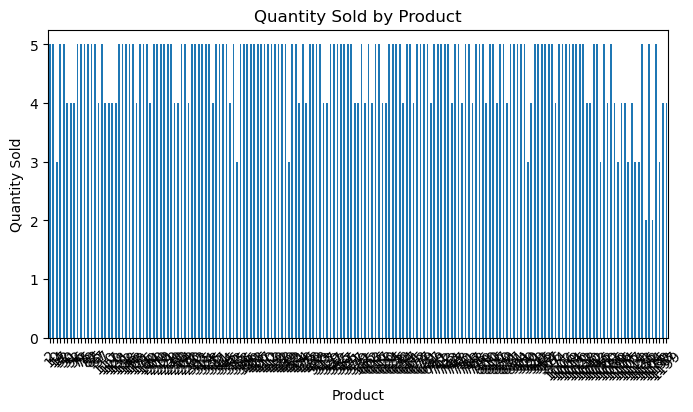

In [51]:
#Chart 
prod_sales.plot(kind="bar",
                   figsize=(8,4))

plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

10. Revenue Analysis

In [52]:
# Which product generate maximum revenue ?
rev_prod = df.groupby('Product')['TotalPrice']
rev_prod.sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

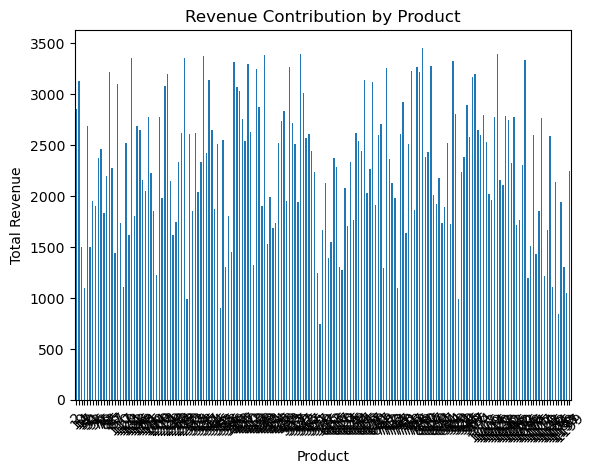

In [53]:
rev_prod.plot(
    kind="bar"
)

plt.title("Revenue Contribution by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

11. Category Analysis


In [54]:
df['Product_Category'].value_counts()

Product_Category
Electronics    852
Furniture      348
Name: count, dtype: int64

In [55]:
cat_revenue = (
    df.groupby("Product_Category")["TotalPrice"]
    .sum()
)

cat_revenue

Product_Category
Electronics    901681.92
Furniture      363080.04
Name: TotalPrice, dtype: float64

In [56]:
category_share = (
    cat_revenue /
    cat_revenue.sum()
)*100

category_share

Product_Category
Electronics    71.292619
Furniture      28.707381
Name: TotalPrice, dtype: float64

FileNotFoundError: [Errno 2] No such file or directory: 'Visualizations/revenue_by_category.png'

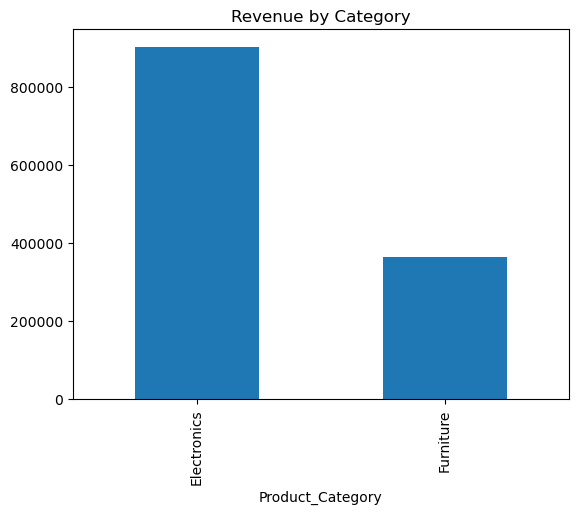

In [57]:
# Chart
cat_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.savefig(
"Visualizations/revenue_by_category.png",
dpi=300,
bbox_inches="tight"
)
plt.show()

12. Time Trend Analysis

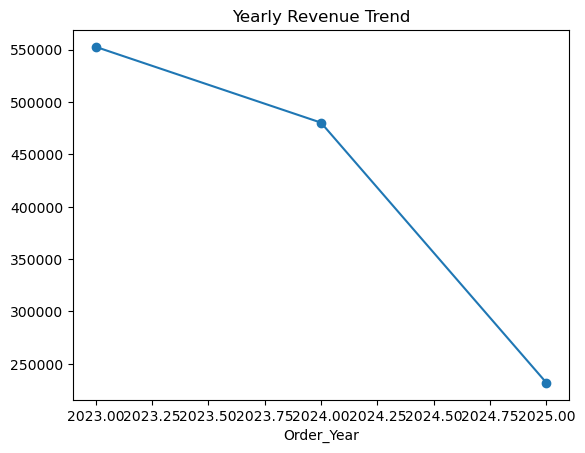

In [ ]:
#Yearly Sales
year_sales = (
    df.groupby("Order_Year")["TotalPrice"]
    .sum()
)

year_sales.plot(kind="line",
                marker="o")

plt.title("Yearly Revenue Trend")
plt.savefig(
"Visualizations/yearly_revenue_trend.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [ ]:
df["Year_Month"] = df["Date"].dt.to_period("M")

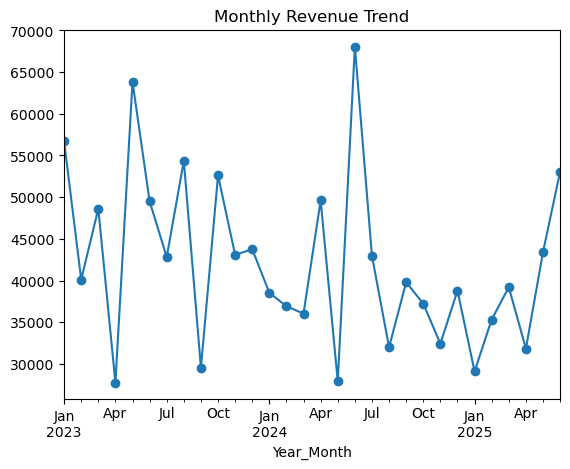

In [ ]:
# Monthly Trend
monthly_sales = (
    df.groupby("Year_Month")["TotalPrice"]
    .sum()
)

monthly_sales.plot(kind="line",
                   marker="o")

plt.title("Monthly Revenue Trend")

plt.savefig(
"Visualizations/monthly_revenue_trend.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

13. Payment Method Analysis

In [ ]:
# Which payment method customers prefer ?
paym = df['PaymentMethod'].value_counts()
paym

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

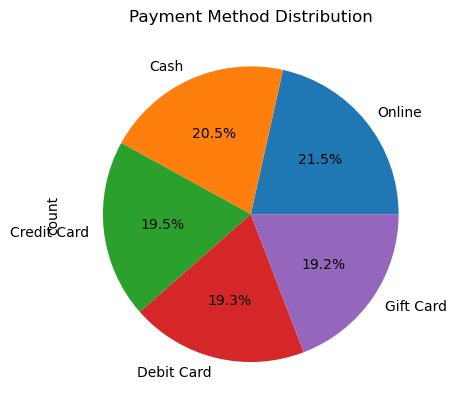

In [ ]:
paym.plot(kind="pie",
             autopct="%1.1f%%")

plt.title("Payment Method Distribution")

plt.savefig(
"Visualizations/payment_method_distribution.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

In [ ]:
paym_rev= df.groupby('PaymentMethod')['TotalPrice'].sum()
paym_rev.sort_values(ascending=False)

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64

In [ ]:
paym_rev_share = (paym_rev/ paym_rev.sum())*100
paym_rev_share.sort_values(ascending=False)

PaymentMethod
Credit Card    20.861446
Online         20.750382
Cash           20.540331
Gift Card      19.475911
Debit Card     18.371930
Name: TotalPrice, dtype: float64

14. Discount Analysis

In [ ]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP    313
None        309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [ ]:

df['Discount_Status'] = np.where(df['CouponCode'].isin(['FREESHIP','SAVE10','WINTER15']),
                         "Discount Applied", "No Discount")

In [ ]:
 # Do discounted orders contribute more revenue ?
discount_analysis = (
    df.groupby('Discount_Status')["TotalPrice"]
    .agg(
        Total_Revenue="sum",
        Average_Order_Value="mean",
        Number_of_Orders="count"
    )
)

discount_analysis

,Total_Revenue,Average_Order_Value,Number_of_Orders
Discount_Status,,,
Discount Applied,942360.55,1057.643715,891
No Discount,322401.41,1043.370259,309


In [ ]:
analysis = (
df.groupby("Discount_Status")
.agg(
    Total_Revenue=("TotalPrice","sum"),
    Average_Order_Value=("TotalPrice","mean"),
    Total_Quantity=("Quantity","sum"),
    Orders=("OrderID","count")
)
)
analysis

,Total_Revenue,Average_Order_Value,Total_Quantity,Orders
Discount_Status,,,,
Discount Applied,942360.55,1057.643715,2594,891
No Discount,322401.41,1043.370259,941,309


15. Order Status Analysis

In [ ]:
df['OrderStatus'].unique()

array(['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending'],
      dtype=object)

In [ ]:
status = (df["OrderStatus"].value_counts(normalize=True))*100
status

OrderStatus
Cancelled    20.833333
Returned     20.583333
Pending      19.750000
Shipped      19.583333
Delivered    19.250000
Name: proportion, dtype: float64

In [ ]:
status_count = df['OrderStatus'].value_counts()
status_count

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

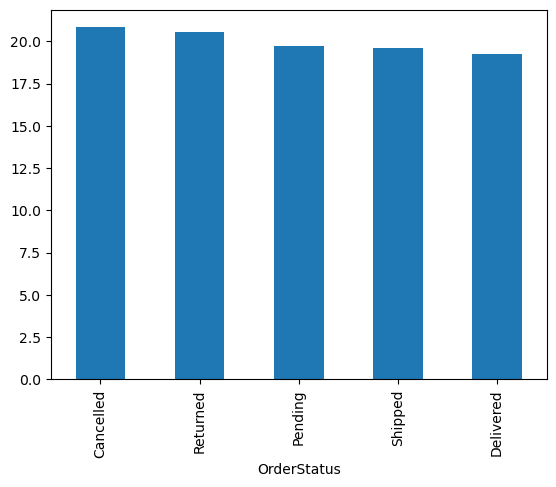

In [ ]:

status.plot(kind="bar")
plt.savefig(
"Visualizations/Order_Status_.png",
dpi=300,
bbox_inches="tight"
)

In [ ]:
# Buisness Grouping 
df['Order_Outcome'] = np.where(df['OrderStatus'].isin(['Cancelled','Returned']),
                               "UnSuccessful", 'Successful')
percent = (df['Order_Outcome'].value_counts(normalize=True))*100
percent

Order_Outcome
Successful      58.583333
UnSuccessful    41.416667
Name: proportion, dtype: float64

In [ ]:
# 41% orders were unsuccesful

16. Customer analysis

In [ ]:
customer_analysis = (
df.groupby("CustomerID")
.agg(
Orders=("OrderID","count"),
Revenue=("TotalPrice","sum"),
 Avg_Order_Value=("TotalPrice","mean")
)
.sort_values("Revenue",ascending=False)
)
customer_analysis.head(10)

,Orders,Revenue,Avg_Order_Value
CustomerID,,,
C38840,2,5723.23,2861.615
C57276,1,3456.40,3456.400
C67260,1,3390.80,3390.800
C13877,1,3384.90,3384.900
C18404,1,3370.20,3370.200
C16775,1,3353.75,3353.750
C65986,1,3352.40,3352.400
C47778,1,3334.00,3334.000
C59183,1,3322.55,3322.550


In [ ]:
# Top customers by spending
top_cust = df.groupby('CustomerID')['TotalPrice']
top_cust.nlargest(5)

CustomerID     
C10002      853    1470.03
C10054      37      153.48
C10126      201    1349.80
C10154      728    1303.04
C10211      991     635.90
                    ...   
C99589      163     641.39
C99683      741    1663.20
C99775      204    1654.84
C99879      225     821.88
C99904      899     646.74
Name: TotalPrice, Length: 1200, dtype: float64

17. Refferal Method Analysis

In [ ]:
df['ReferralSource'].value_counts(normalize=True)*100


ReferralSource
Instagram    21.583333
Email        20.833333
Google       20.083333
Facebook     19.000000
Referral     18.500000
Name: proportion, dtype: float64

18. Outlier Detection

In [ ]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR


outliers = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

outliers

,OrderID,Date,CustomerID,Product,Product_Category,Quantity,UnitPrice,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Order_Year,Order_Month,Year_Month,Discount_Status,Order_Outcome
107,ORD200107,2023-03-27,C16775,Printer,Electronics,5,670.75,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75,2023,3,2023-03,Discount Applied,Successful
326,ORD200326,2024-07-01,C65986,Laptop,Electronics,5,670.48,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40,2024,7,2024-07,Discount Applied,UnSuccessful
328,ORD200328,2023-02-28,C18404,Tablet,Electronics,5,674.04,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20,2023,2,2023-02,Discount Applied,UnSuccessful
469,ORD200469,2023-11-26,C13877,Chair,Furniture,5,676.98,Cash,Cancelled,TRK17254691,5,None,Facebook,3384.90,2023,11,2023-11,No Discount,UnSuccessful
632,ORD200632,2023-05-02,C67260,Laptop,Electronics,5,678.16,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80,2023,5,2023-05,Discount Applied,Successful
789,ORD200789,2023-08-17,C57276,Tablet,Electronics,5,691.28,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40,2023,8,2023-08,Discount Applied,Successful
1065,ORD201065,2023-10-30,C47778,Printer,Electronics,5,666.80,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00,2023,10,2023-10,Discount Applied,Successful
1122,ORD201122,2023-06-07,C38840,Monitor,Electronics,5,678.19,Online,Returned,TRK32496970,8,None,Facebook,3390.95,2023,6,2023-06,No Discount,UnSuccessful


In [ ]:
outliers[
[
"OrderID",
"Product",
"CustomerID",
"TotalPrice"
]
].sort_values('TotalPrice',ascending=False)

,OrderID,Product,CustomerID,TotalPrice
789,ORD200789,Tablet,C57276,3456.40
1122,ORD201122,Monitor,C38840,3390.95
632,ORD200632,Laptop,C67260,3390.80
469,ORD200469,Chair,C13877,3384.90
328,ORD200328,Tablet,C18404,3370.20
107,ORD200107,Printer,C16775,3353.75
326,ORD200326,Laptop,C65986,3352.40
1065,ORD201065,Printer,C47778,3334.00


In [ ]:
outliers["Product"].value_counts()

Product
Printer    2
Laptop     2
Tablet     2
Chair      1
Monitor    1
Name: count, dtype: int64

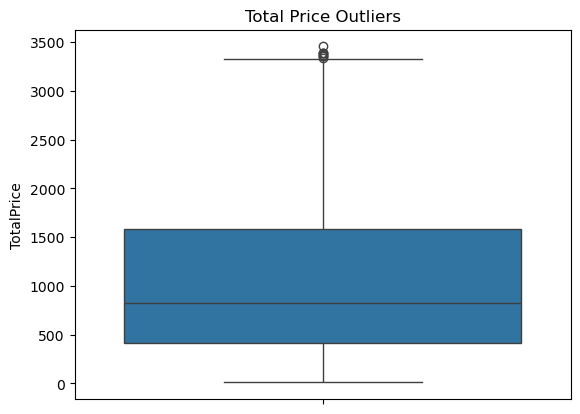

In [ ]:
sns.boxplot(df["TotalPrice"])

plt.title("Total Price Outliers")

plt.savefig(
"Visualizations/Revenue_Outliers.png",
dpi=300,
bbox_inches="tight"
)

plt.show()

19. Correlation Analysis

FileNotFoundError: [Errno 2] No such file or directory: 'Visualizations/correlation_matrix.png'

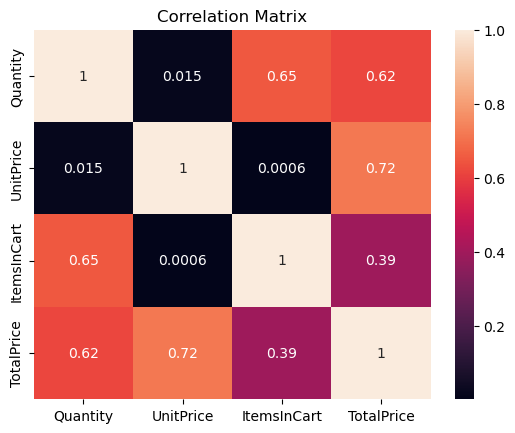

In [ ]:
corr = df[
[
"Quantity",
"UnitPrice",
"ItemsInCart",
"TotalPrice"
]
].corr()


sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")
plt.savefig(
"Visualizations/correlation_matrix.png",
dpi=300,
bbox_inches="tight"
)
plt.show()

UnitPrice has strongest correlation with TotalPrice.

This indicates high-priced products contribute significantly to revenue.

Connecting to posgresql

In [58]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
)

In [59]:
%pip install psycopg2-binary SQLAlchemy

Note: you may need to restart the kernel to use updated packages.


In [60]:
from sqlalchemy import create_engine
import psycopg2

In [61]:
#Connect to database
username = "postgres"
password = "Passadi2026"
host = "localhost"
port = "5432"
database = "E_commerce_orders"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")
print("Connected Successfully")

Connected Successfully


In [62]:
# Load dataframe into Postgresql
table_name = 'orders'
df.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'orders' in database 'E_commerce_orders'.
